In [67]:
import pytensor
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp
import inspect
import xarray as xr
import sys
import matplotlib.pyplot as plt
import multiprocessing
import statsmodels.api as sm

In [2]:
np.random.seed(1)

#### Bayesian Logistic Regression and Interpret the Posterior

In [3]:
# Simulating binary data.

n = 200

x = np.random.normal(0, 1, n)

true_intercept = -0.5
true_slope = 2.0

logits = true_intercept + true_slope * x

probability = 1 / (1 + np.exp(-logits))

y = np.random.binomial(
    n=1,
    p=probability,
    size=n
)

print("Number of observations: ", n)
print("Number of successes: ", np.sum(y))

Number of observations:  200
Number of successes:  84


In [4]:
# Building the Bayesian logistic regression model.

with pm.Model() as logistic_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    logits = intercept + slope * x

    p = pm.math.sigmoid(logits)

    outcome = pm.Bernoulli(
        "outcome",
        p=p,
        observed=y
    )

    logistic_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


Posterior Summary:
              mean     sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  -0.803  0.201     -1.2    -0.42     6046     5530  1.00    0.0026  0.0019
slope       2.292  0.334      1.7        3     5753     5415  1.00    0.0044  0.0032

Posterior Means:
Intercept: -0.803
Slope: 2.292


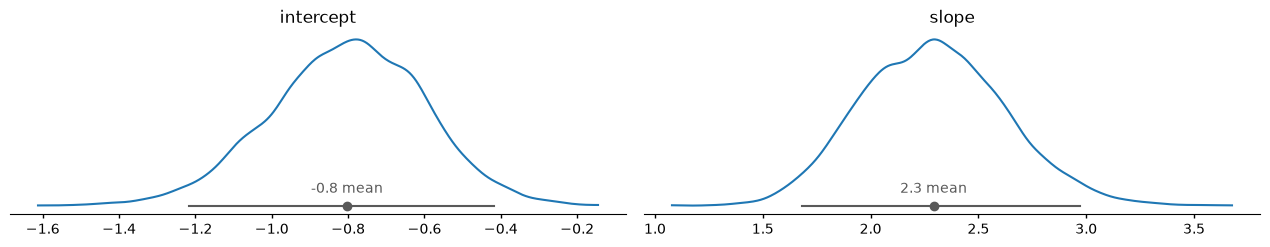

In [5]:
# Posterior summary.

summary = az.summary(
    logistic_trace,
    ci_prob=0.95
)


print("Posterior Summary:\n", summary)

print("\nPosterior Means:")

print("Intercept:", round(summary.loc["intercept", "mean"], 3))

print("Slope:", round(summary.loc["slope", "mean"], 3))

# Posterior distributions.

azp.plot_dist(
    logistic_trace,
    var_names=["intercept", "slope"],
    ci_prob=0.95
)

plt.tight_layout()

plt.show()

In [6]:
print(az.__version__)
print([x for x in dir(az) if x.startswith("plot_")])

1.3.0
['plot_autocorr', 'plot_bf', 'plot_collection', 'plot_compare', 'plot_convergence_dist', 'plot_dgof', 'plot_dgof_dist', 'plot_dist', 'plot_ecdf_pit', 'plot_energy', 'plot_ess', 'plot_ess_evolution', 'plot_forest', 'plot_khat', 'plot_lm', 'plot_loo_interval', 'plot_loo_pava', 'plot_loo_pit', 'plot_matrix', 'plot_mcse', 'plot_pair', 'plot_pair_focus', 'plot_parallel', 'plot_ppc_censored', 'plot_ppc_dist', 'plot_ppc_dist_pit', 'plot_ppc_interval', 'plot_ppc_pava', 'plot_ppc_pava_residuals', 'plot_ppc_pit', 'plot_ppc_rootogram', 'plot_ppc_tstat', 'plot_prior_posterior', 'plot_psense_dist', 'plot_psense_quantities', 'plot_rank', 'plot_rank_dist', 'plot_ridge', 'plot_trace', 'plot_trace_dist']


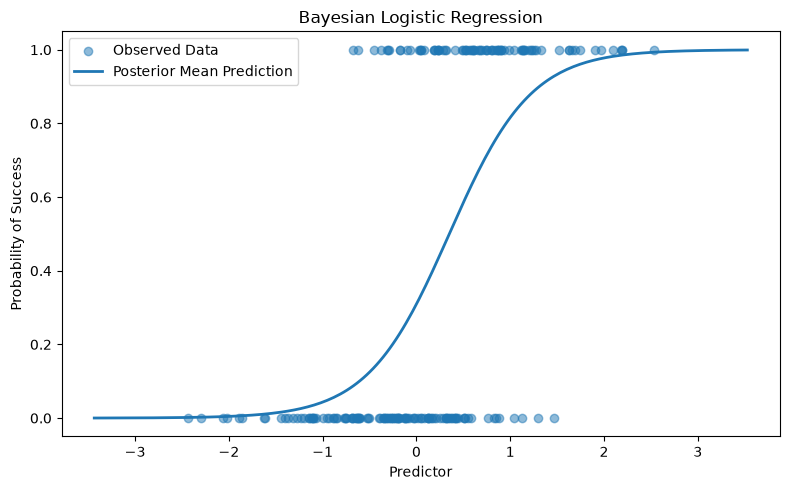

In [7]:
# Decision boundary

posterior_intercept = (
    logistic_trace.posterior["intercept"]
    .mean(dim=("chain", "draw"))
    .values
)

posterior_slope = (
    logistic_trace.posterior["slope"]
    .mean(dim=("chain", "draw"))
    .values
)

x_grid = np.linspace(
    x.min() - 1,
    x.max() + 1,
    200
)

predicted_probability = 1 / (1 + np.exp( - (posterior_intercept + posterior_slope * x_grid)))

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_grid,
    predicted_probability,
    linewidth=2,
    label="Posterior Mean Prediction"
)

plt.title("Bayesian Logistic Regression")
plt.xlabel("Predictor")
plt.ylabel("Probability of Success")

plt.legend()

plt.tight_layout()

plt.show()

#### Bayesian Poisson Regression and Count Data

In [8]:
# Simulating count data.

n = 200

x = np.random.uniform(0, 5, n)

true_intercept = 1.0
true_slope = 0.4

log_rate = true_intercept + true_slope * x

rate = np.exp(log_rate)

counts = np.random.poisson(
    lam=rate,
    size=n
)

print("Number of observations: ", n)
print("Average count: ", round(counts.mean(), 2))

Number of observations:  200
Average count:  8.7


In [9]:
# Building the Bayesian Poisson regression model.

with pm.Model() as poisson_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    log_lambda = intercept + slope * x

    lambda_ = pm.math.exp(log_lambda)

    outcome = pm.Poisson(
        "outcome",
        mu=lambda_,
        observed=counts
    )

    poisson_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

/home/erfan/projects/research/computational-cognitive-science-training/.venv/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/erfan/projects/research/computational-cognitive-science-training/.venv/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/erfan/projects/research/computational-cognitive-science-training/.venv/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/erfan/projects/research/computational-cognitive-science-training/.venv/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


Posterior Summary:
              mean      sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
intercept    1.04   0.063     0.92      1.2     1914     2094  1.00    0.0014    0.001
slope      0.3977  0.0183     0.36     0.43     1911     2019  1.00   0.00042  0.00029

Posterior Means: 
Intercept: 1.04
Slope: 0.398


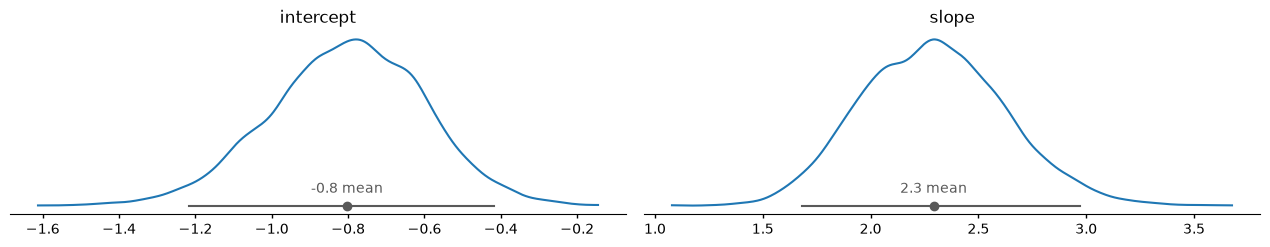

In [11]:
# Posterior summary

summary = az.summary(
    poisson_trace,
    ci_prob=0.95
)

print("Posterior Summary:\n", summary)

print("\nPosterior Means: ")

print("Intercept:",
      round(summary.loc["intercept", "mean"], 3))

print("Slope:",
      round(summary.loc["slope", "mean"], 3))

# Posterior distributions.

azp.plot_dist(
    logistic_trace,
    var_names=["intercept", "slope"],
    ci_prob=0.95
)

plt.tight_layout()

plt.show()

In [12]:
# Frequentist Logistic Regression

X_logistic = sm.add_constant(x)

logistic_model = sm.Logit(y, X_logistic)

logistic_result = logistic_model.fit(disp=False)

print("Frequentist Logistic Regression:\n", logistic_result.summary())

# Bayesian Logistic Regression

bayes_logistic = az.summary(
    logistic_trace,
    var_names=["intercept", "slope"],
    ci_prob=0.95
)

print("\nBayesian Logistic Regression:\n", bayes_logistic)

Frequentist Logistic Regression:
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:               9.606e-05
Time:                        15:07:19   Log-Likelihood:                -136.05
converged:                       True   LL-Null:                       -136.06
Covariance Type:            nonrobust   LLR p-value:                    0.8716
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3625      0.285     -1.274      0.203      -0.920       0.195
x1             0.0163      0.101      0.162      0.872      -0.182       0.214

Bayesian Logistic

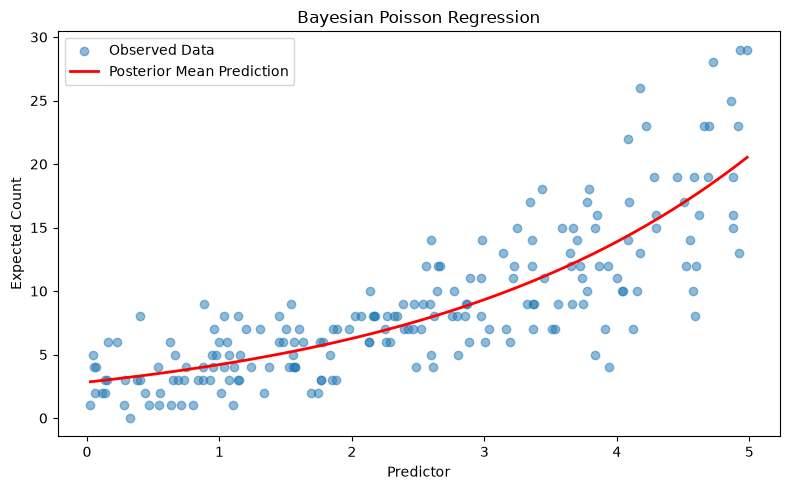

In [13]:
# Visualizing predicted counts.

posterior_intercept = (
    poisson_trace.posterior["intercept"]
    .mean(dim=("chain", "draw"))
    .values
)

posterior_slope = (
    poisson_trace.posterior["slope"]
    .mean(dim=("chain", "draw"))
    .values
)

x_grid = np.linspace(
    x.min(),
    x.max(),
    200
)

predicted_counts = np.exp(
    posterior_intercept +
    posterior_slope * x_grid
)

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    counts,
    alpha=0.5,
    label="Observed Data"
)

plt.plot(
    x_grid,
    predicted_counts,
    color="red",
    linewidth=2,
    label="Posterior Mean Prediction"
)

plt.title("Bayesian Poisson Regression")
plt.xlabel("Predictor")
plt.ylabel("Expected Count")

plt.legend()

plt.tight_layout()

plt.show()

#### Compare Bayesian GLMs with Frequentist GLMs

In [30]:
# Frequentist Poisson Regression

X_poisson = sm.add_constant(x)

poisson_model = sm.GLM(
    counts,
    X_poisson,
    family=sm.families.Poisson()
)

poisson_result = poisson_model.fit()

print("Frequentist Poisson Regression:\n", poisson_result.summary())

# Bayesian Poisson Regression

bayes_poisson = az.summary(
    poisson_trace,
    var_names=["intercept", "slope"],
    ci_prob=0.95
)

print("Bayesian Poisson Regression:\n", bayes_poisson)

Frequentist Poisson Regression:
                  Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  200
Model:                            GLM   Df Residuals:                      198
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -745.73
Date:                Fri, 04 Sep 2026   Deviance:                       734.99
Time:                        15:15:48   Pearson chi2:                     785.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01681
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.15

In [31]:
# Comparing interval estimates.

print(
    "95% Frequentist Confidence Intervals (Logistic):\n",
    logistic_result.conf_int()
)

print(
    "\n95% Bayesian Credible Intervals (Logistic):\n",
    bayes_logistic[["mean", "eti95_lb", "eti95_ub"]]
)

print(
    "\n95% Frequentist Confidence Intervals (Poisson):\n",
    poisson_result.conf_int()
)

print(
    "\n95% Bayesian Credible Intervals (Poisson):\n",
    bayes_poisson[["mean", "eti95_lb", "eti95_ub"]]
)

95% Frequentist Confidence Intervals (Logistic):
 [[-0.92020316  0.19524626]
 [-0.1816265   0.21428382]]

95% Bayesian Credible Intervals (Logistic):
              mean eti95_lb eti95_ub
intercept  -0.803     -1.2    -0.42
slope       2.292      1.7        3

95% Frequentist Confidence Intervals (Poisson):
 [[ 2.11162895  2.2061857 ]
 [-0.00295987  0.09584841]]

95% Bayesian Credible Intervals (Poisson):
              mean eti95_lb eti95_ub
intercept    1.04     0.92      1.2
slope      0.3977     0.36     0.43


#### Compare Different Priors in Bayesian Logistic Regression

In [32]:
# Simulating binary data.

n = 200

x = np.random.normal(0, 1, n)

true_intercept = -0.5
true_slope = 2.0

logits = true_intercept + true_slope * x

probability = 1 / (1 + np.exp(-logits))

y = np.random.binomial(
    n=1,
    p=probability,
    size=n
)

print("Number of observations: ", n)

Number of observations:  200


In [33]:
# Model 1: Flat prior (very weak Normal).

with pm.Model() as flat_prior_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=100
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=100
    )

    p = pm.math.sigmoid(intercept + slope * x)

    pm.Bernoulli(
        "y",
        p=p,
        observed=y
    )

    flat_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


In [34]:
# Model 2: Normal(0,1) prior.

with pm.Model() as normal_prior_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=1
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=1
    )

    p = pm.math.sigmoid(intercept + slope * x)

    pm.Bernoulli(
        "y",
        p=p,
        observed=y
    )

    normal_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


In [35]:
# Model 3: Cauchy prior.

with pm.Model() as cauchy_prior_model:

    intercept = pm.Cauchy(
        "intercept",
        alpha=0,
        beta=2.5
    )

    slope = pm.Cauchy(
        "slope",
        alpha=0,
        beta=2.5
    )

    p = pm.math.sigmoid(intercept + slope * x)

    pm.Bernoulli(
        "y",
        p=p,
        observed=y
    )

    cauchy_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


In [36]:
# Posterior summaries

print("Flat Prior:\n", az.summary(flat_trace, var_names=["intercept", "slope"]))

print("\nNormal(0,1) Prior:\n", az.summary(normal_trace, var_names=["intercept", "slope"]))

print("\nCauchy(0,2.5) Prior:\n", az.summary(cauchy_trace, var_names=["intercept", "slope"]))

Flat Prior:
              mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  -0.443  0.184    -0.74    -0.15     7905     5574  1.00    0.0021  0.0014
slope       1.969  0.286      1.5      2.4     7419     5348  1.00    0.0034  0.0024

Normal(0,1) Prior:
              mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  -0.418  0.179    -0.71    -0.13     6861     4963  1.00    0.0022  0.0016
slope       1.824  0.263      1.4      2.3     7077     5255  1.00    0.0031  0.0022

Cauchy(0,2.5) Prior:
              mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  -0.436  0.181    -0.73    -0.15     7386     5318  1.00    0.0021  0.0015
slope       1.936  0.286      1.5      2.4     7630     5743  1.00    0.0033  0.0024


#### Prior Predictive Simulation

In [37]:
# Creating predictor values.

n = 200

x = np.random.normal(0, 1, n)

In [38]:
# Building the model.

with pm.Model() as prior_predictive_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=1
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=1
    )

    p = pm.math.sigmoid(
        intercept + slope * x
    )

    outcome = pm.Bernoulli(
        "outcome",
        p=p
    )

    prior = pm.sample_prior_predictive(
        draws=500,
        random_seed=42
    )

Sampling: [intercept, outcome, slope]


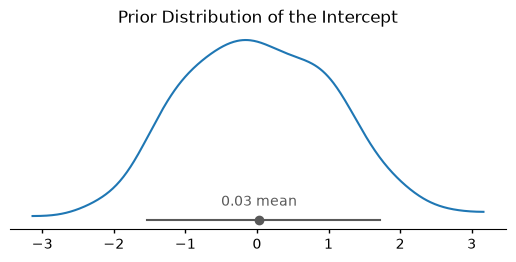

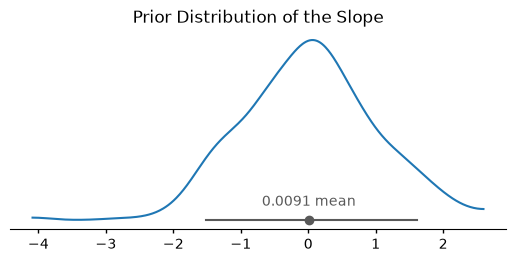

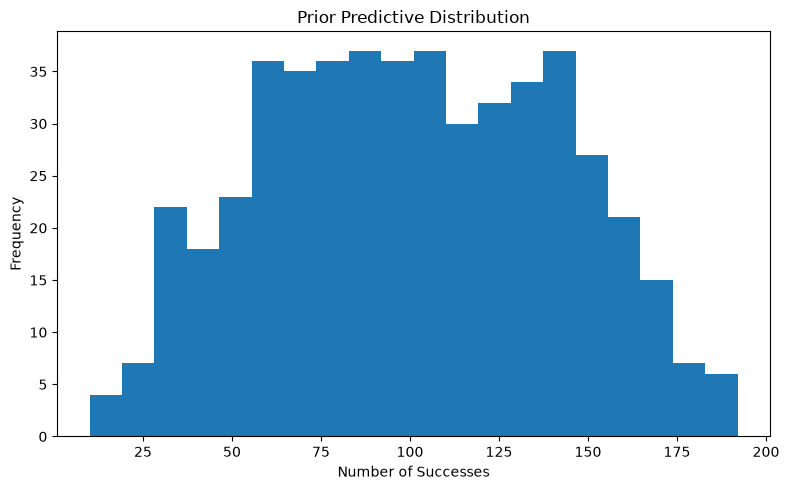

Average predicted successes: 100.85
Minimum predicted successes: 10
Maximum predicted successes: 192


In [39]:
# Visualizing prior distributions.

import arviz_plots as azp

azp.plot_dist(
    prior,
    var_names=["intercept"],
    group="prior"
)

plt.title("Prior Distribution of the Intercept")
plt.show()

azp.plot_dist(
    prior,
    var_names=["slope"],
    group="prior"
)

plt.title("Prior Distribution of the Slope")
plt.show()


# Visualizing prior predictive outcomes.

predicted_successes = (
    prior.prior["outcome"]
    .sum(dim="outcome_dim_0")
    .values
)

predicted_successes = predicted_successes.ravel()

plt.figure(figsize=(8, 5))

plt.hist(
    predicted_successes,
    bins=20
)

plt.title("Prior Predictive Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()


# Summary.

print(
    "Average predicted successes:",
    round(predicted_successes.mean(), 2)
)

print(
    "Minimum predicted successes:",
    predicted_successes.min()
)

print(
    "Maximum predicted successes:",
    predicted_successes.max()
)

#### Effect of Different Priors

In [41]:
# Posterior summaries.

flat_summary = az.summary(
    flat_trace,
    var_names=["intercept", "slope"],
    ci_prob=0.95
)

normal_summary = az.summary(
    normal_trace,
    var_names=["intercept", "slope"],
    ci_prob=0.95
)

cauchy_summary = az.summary(
    cauchy_trace,
    var_names=["intercept", "slope"],
    ci_prob=0.95
)

print("Flat Prior:\n", flat_summary)

print("\nNormal(0,1) Prior:\n", normal_summary)

print("\nCauchy(0,2.5) Prior:\n", cauchy_summary)


Flat Prior:
              mean     sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  -0.443  0.184    -0.81   -0.095     7905     5574  1.00    0.0021  0.0014
slope       1.969  0.286      1.4      2.6     7419     5348  1.00    0.0034  0.0024

Normal(0,1) Prior:
              mean     sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  -0.418  0.179    -0.77   -0.067     6861     4963  1.00    0.0022  0.0016
slope       1.824  0.263      1.3      2.4     7077     5255  1.00    0.0031  0.0022

Cauchy(0,2.5) Prior:
              mean     sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  -0.436  0.181    -0.79   -0.085     7386     5318  1.00    0.0021  0.0015
slope       1.936  0.286      1.4      2.5     7630     5743  1.00    0.0033  0.0024


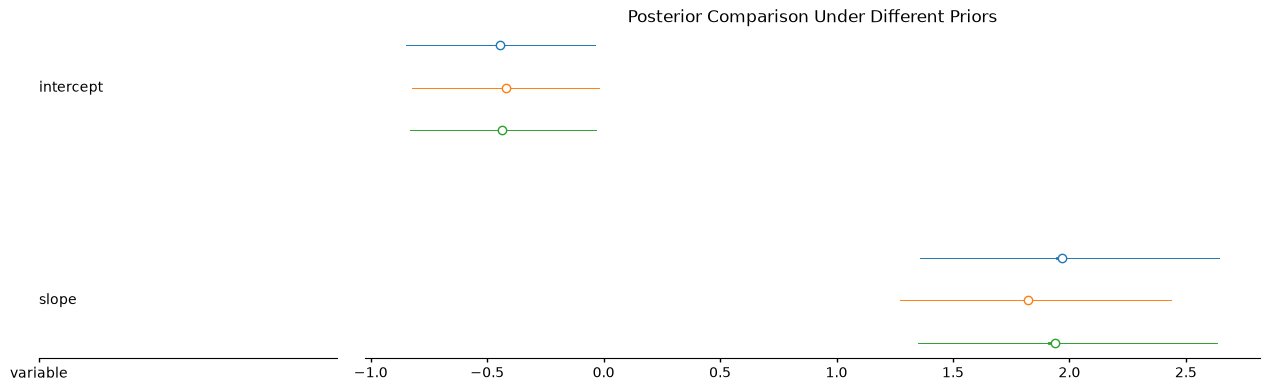

In [46]:
# Posterior comparison plots.

import arviz_plots as azp

azp.plot_forest(
    {
        "Flat": flat_trace,
        "Normal(0,1)": normal_trace,
        "Cauchy(0,2.5)": cauchy_trace
    },
    var_names=["intercept", "slope"],
    combined=True,
    ci_probs=(0.025, 0.975)
)

plt.title("Posterior Comparison Under Different Priors")

plt.tight_layout()

plt.show()

In [47]:
# Posterior means.

print("Flat Prior:", flat_summary["mean"].round(3).to_dict())

print("Normal(0,1) Prior:", normal_summary["mean"].round(3).to_dict())

print("Cauchy(0,2.5) Prior:", cauchy_summary["mean"].round(3).to_dict())

Flat Prior: {'intercept': -0.443, 'slope': 1.969}
Normal(0,1) Prior: {'intercept': -0.418, 'slope': 1.824}
Cauchy(0,2.5) Prior: {'intercept': -0.436, 'slope': 1.936}


#### Posterior Summary Statistics and Credible Intervals

In [51]:
# Computing posterior summary statistics.

summary = az.summary(
    logistic_trace,
    var_names=["intercept", "slope"],
    ci_prob=0.95
)

print("Posterior Summary:\n", summary)

Posterior Summary:
              mean     sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept  -0.803  0.201     -1.2    -0.42     6046     5530  1.00    0.0026  0.0019
slope       2.292  0.334      1.7        3     5753     5415  1.00    0.0044  0.0032


In [52]:
# Posterior means.

intercept_mean = summary.loc["intercept", "mean"]
slope_mean = summary.loc["slope", "mean"]

print("Intercept:", round(intercept_mean, 3))
print("Slope:", round(slope_mean, 3))

Intercept: -0.803
Slope: 2.292


In [54]:
# Posterior medians.

intercept_samples = (
    logistic_trace.posterior["intercept"]
    .values
    .flatten()
)

slope_samples = (
    logistic_trace.posterior["slope"]
    .values
    .flatten()
)

intercept_median = np.median(intercept_samples)
slope_median = np.median(slope_samples)

print("Intercept:", round(intercept_median, 3))
print("Slope:", round(slope_median, 3))

Intercept: -0.797
Slope: 2.287


In [56]:
# 95% Credible intervals.

print(
    "Intercept: [",
    round(summary.loc["intercept", "eti95_lb"], 3),
    ",",
    round(summary.loc["intercept", "eti95_ub"], 3),
    "]"
)

print(
    "Slope: [",
    round(summary.loc["slope", "eti95_lb"], 3),
    ",",
    round(summary.loc["slope", "eti95_ub"], 3),
    "]"
)

Intercept: [ -1.216 , -0.419 ]
Slope: [ 1.68 , 2.97 ]


In [57]:
# Posterior standard deviations.

print(
    "Intercept:",
    round(summary.loc["intercept", "sd"], 3)
)

print(
    "Slope:",
    round(summary.loc["slope", "sd"], 3)
)

Intercept: 0.201
Slope: 0.334


#### Effect Threshold

In [58]:
# Extracting posterior samples.

slope_samples = (
    logistic_trace.posterior["slope"]
    .values
    .flatten()
)

In [59]:
# Computing posterior probabilities.

prob_positive = np.mean(slope_samples > 0)

prob_above_threshold = np.mean(slope_samples > 0.2)

print("P(slope > 0): ", round(prob_positive, 4))

print("P(slope > 0.2): ", round(prob_above_threshold, 4))

P(slope > 0):  1.0
P(slope > 0.2):  1.0


In [60]:
# Computing additional probabilities.

prob_negative = np.mean(slope_samples < 0)

prob_between = np.mean((slope_samples > 1.5) & (slope_samples < 2.5))

print("P(slope < 0):", round(prob_negative, 4))

print("P(1.5 < slope < 2.5):", round(prob_between, 4))

P(slope < 0): 0.0
P(1.5 < slope < 2.5): 0.7341


#### Posterior Results

In [61]:
# Extracting posterior samples.

intercept_samples = (
    logistic_trace.posterior["intercept"]
    .values
    .flatten()
)

slope_samples = (
    logistic_trace.posterior["slope"]
    .values
    .flatten()
)

In [62]:
# Computing posterior summaries.

intercept_mean = np.mean(intercept_samples)
slope_mean = np.mean(slope_samples)

intercept_ci = np.percentile(
    intercept_samples,
    [2.5, 97.5]
)

slope_ci = np.percentile(
    slope_samples,
    [2.5, 97.5]
)

prob_positive = np.mean(slope_samples > 0)

In [63]:
# Reporting the results.

print("Intercept:")

print("Posterior mean: ", round(intercept_mean, 3))

print("95% Credible Interval: ",
      f"[{intercept_ci[0]:.3f}, {intercept_ci[1]:.3f}]")

print("\nSlope:")

print("Posterior mean: ", round(slope_mean, 3))

print("95% Credible Interval: ",
      f"[{slope_ci[0]:.3f}, {slope_ci[1]:.3f}]")

print("P(slope > 0):", round(prob_positive, 4))

print("\nInterpretation:")

if prob_positive > 0.95:
    print("There is strong Bayesian evidence that the predictor has a positive effect on the outcome.")
elif prob_positive > 0.80:
    print("There is moderate Bayesian evidence that the predictor has a positive effect on the outcome.")
else:
    print("The evidence for a positive effect is weak or uncertain.")

print("\nThe posterior mean estimates the most plausible value of the effect after combining the prior information with the observed data.")
print("The 95% credible interval represents the range that contains the parameter with 95% posterior probability.")
print("The posterior probability directly quantifies the probability that the effect is positive.")

Intercept:
Posterior mean:  -0.803
95% Credible Interval:  [-1.216, -0.419]

Slope:
Posterior mean:  2.292
95% Credible Interval:  [1.680, 2.970]
P(slope > 0): 1.0

Interpretation:
There is strong Bayesian evidence that the predictor has a positive effect on the outcome.

The posterior mean estimates the most plausible value of the effect after combining the prior information with the observed data.
The 95% credible interval represents the range that contains the parameter with 95% posterior probability.
The posterior probability directly quantifies the probability that the effect is positive.


#### Generate Posterior Predictive Datasets

In [64]:
# Rebuilding the Bayesian logistic regression model.

with pm.Model() as bayesian_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    p = pm.math.sigmoid(
        intercept + slope * x
    )

    outcome = pm.Bernoulli(
        "outcome",
        p=p,
        observed=y
    )

# Generating posterior predictive samples.

with bayesian_model:

    posterior_predictive = pm.sample_posterior_predictive(
        logistic_trace,
        random_seed=42
    )

# Displaying the generated data.


print("InferenceData Groups:\n", posterior_predictive.groups())

print("\nPosterior Predictive Variables:\n", posterior_predictive.posterior_predictive.data_vars)

print("\nPosterior Predictive Shape:\n", posterior_predictive.posterior_predictive["outcome"].shape)

Sampling: [outcome]


Output()

TypeError: 'tuple' object is not callable

#### Posterior Predictive Check

/home/erfan/projects/research/computational-cognitive-science-training/.venv/lib/python3.13/site-packages/arviz_plots/plots/utils_ppc.py:67: UserWarning: Variables outcome in 'observed_data' look binary. For binary outcomes, plot_ppc_pava may be more appropriate.
  warn_if_binary(observed_dist, predictive_dist)
/home/erfan/projects/research/computational-cognitive-science-training/.venv/lib/python3.13/site-packages/arviz_plots/plots/utils_ppc.py:67: UserWarning: Variables outcome in 'predictive' look binary. For binary outcomes, plot_ppc_pava may be more appropriate.
  warn_if_binary(observed_dist, predictive_dist)
/home/erfan/projects/research/computational-cognitive-science-training/.venv/lib/python3.13/site-packages/arviz_plots/plots/utils_ppc.py:69: UserWarning: Variables outcome in 'observed' look discrete.
Consider using plot_ppc variants specific for discrete data, such as plot_ppc_pava or plot_ppc_rootogram.
  warn_if_discrete(observed_dist, predictive_dist, kind)
/home/erfan/p

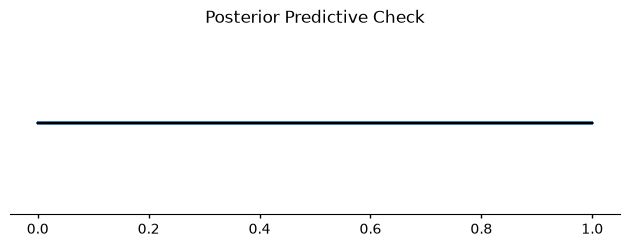

In [70]:
# Posterior Predictive Check (Observed vs Simulated).

azp.plot_ppc_dist(
    posterior_predictive,
    var_names=["outcome"],
    group="posterior_predictive",
    num_samples=100
)

plt.title("Posterior Predictive Check")
plt.tight_layout()
plt.show()

In [72]:
# Comparing summary statistics.

observed = posterior_predictive.observed_data["outcome"].values

predicted = (
    posterior_predictive.posterior_predictive["outcome"]
    .values
)

# Flatten chains and draws.

predicted = predicted.reshape(-1, predicted.shape[-1])

observed_mean = observed.mean()
observed_sd = observed.std()

predicted_means = predicted.mean(axis=1)
predicted_sds = predicted.std(axis=1)

print("Mean: ", round(observed_mean, 3))

print("Standard deviation: ", round(observed_sd, 3))

print("Average mean: ", round(predicted_means.mean(), 3))

print("Average standard deviation:", round(predicted_sds.mean(), 3))

Mean:  0.415
Standard deviation:  0.493
Average mean:  0.392
Average standard deviation: 0.487


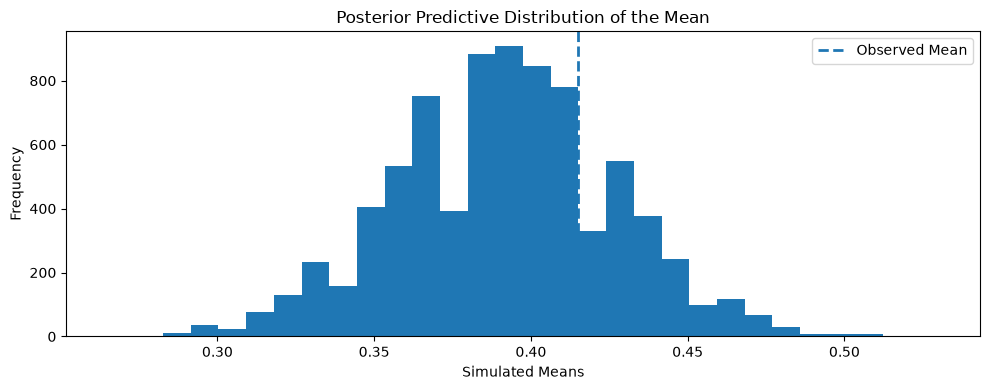

In [73]:
# Distribution of simulated summary statistics.

plt.figure(figsize=(10, 4))

plt.hist(predicted_means, bins=30)

plt.axvline(
    observed_mean,
    linestyle="--",
    linewidth=2,
    label="Observed Mean"
)

plt.title("Posterior Predictive Distribution of the Mean")
plt.xlabel("Simulated Means")
plt.ylabel("Frequency")


plt.legend()

plt.tight_layout()

plt.show()

#### Identify Model Misfit

In [74]:
# Computing observed statistics.

observed = posterior_predictive.observed_data["outcome"].values

observed_mean = observed.mean()

observed_sd = observed.std()

observed_q25 = np.percentile(observed, 25)

observed_q75 = np.percentile(observed, 75)


In [75]:
# Computing simulated statistics.

predicted = (
    posterior_predictive.posterior_predictive["outcome"]
    .values
)

# Merging chains and draws.

predicted = predicted.reshape(-1, predicted.shape[-1])

simulated_means = predicted.mean(axis=1)

simulated_sds = predicted.std(axis=1)

simulated_q25 = np.percentile(predicted, 25, axis=1)

simulated_q75 = np.percentile(predicted, 75, axis=1)

In [76]:
# Comparing observed and simulated statistics.

print("Observed Statistics")
print("Mean:", round(observed_mean, 3))
print("Standard deviation:", round(observed_sd, 3))
print("25th percentile:", round(observed_q25, 3))
print("75th percentile:", round(observed_q75, 3))

print("\nPosterior Predictive Statistics")
print("Mean:", round(simulated_means.mean(), 3))
print("Standard deviation:", round(simulated_sds.mean(), 3))
print("25th percentile:", round(simulated_q25.mean(), 3))
print("75th percentile:", round(simulated_q75.mean(), 3))

Observed Statistics
Mean: 0.415
Standard deviation: 0.493
25th percentile: 0.0
75th percentile: 1.0

Posterior Predictive Statistics
Mean: 0.392
Standard deviation: 0.487
25th percentile: 0.0
75th percentile: 1.0


In [77]:
# Assessing model fit.

print("Model Assessment")

mean_ok = (simulated_means.min() <= observed_mean <= simulated_means.max())

sd_ok = (simulated_sds.min() <= observed_sd <= simulated_sds.max())

if mean_ok and sd_ok:
    print("The observed data are consistent with the posterior predictive distribution.")
    print("There is no obvious evidence of model misfit.")
else:
    print("The observed data differ noticeably from the posterior predictive distribution.")
    print("The model may require revision.")

Model Assessment
The observed data are consistent with the posterior predictive distribution.
There is no obvious evidence of model misfit.


Possible causes of model misfit:
- Important predictors may be missing.
- The likelihood may not match the data.
- The prior distributions may be inappropriate.
- A more flexible or hierarchical model may be needed.